In [10]:
import os
import glob
import textwrap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_curve, auc
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

TIMESTAMP = "20260913182453"

current_dir = os.getcwd()
if not os.path.exists(os.path.join(current_dir, 'src')):
    root_dir = os.path.abspath(os.path.join(current_dir, '..'))
    os.chdir(root_dir)

LOG_DIR = os.path.join("data", "augmented", TIMESTAMP, "augmented_log")
MERGED_DIR = os.path.join("data", "augmented", TIMESTAMP, "merged", "balanced")
RAW_DATA_PATH = os.path.join("data", "raw", "sms_spam_indo.csv")

output_fig_dir = os.path.join("results", "figures")
output_tbl_dir = os.path.join("results", "tables")
os.makedirs(output_fig_dir, exist_ok=True)
os.makedirs(output_tbl_dir, exist_ok=True)

sns.set_theme(style="ticks", context="paper", font_scale=1.2)
plt.rcParams.update({
    'figure.dpi': 300,           
    'savefig.dpi': 300,
    'axes.spines.top': False,     
    'axes.spines.right': False,  
    'font.family': 'serif',
})

def export_table_to_png(df, filename, title=None, wrap_width=60):
    df_plot = df.copy()
    
    for col in df_plot.columns:
        if df_plot[col].dtype == 'object':
            df_plot[col] = df_plot[col].apply(lambda x: textwrap.fill(str(x), width=wrap_width) if pd.notnull(x) else x)
            
    fig_width = min(max(len(df_plot.columns) * 2.5, 8), 20)
    fig_height = min(max(len(df_plot) * 0.5 + 1.5, 3), 25)
    
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    ax.axis('off')
    
    if title:
        ax.set_title(title, fontweight='bold', fontsize=14, pad=15)
    
    table = ax.table(cellText=df_plot.values, colLabels=df_plot.columns, cellLoc='center', loc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.8)
    
    for (i, j), cell in table.get_celld().items():
        cell.set_edgecolor('black')
        cell.set_linewidth(0)
        if i == 0:
            cell.set_text_props(weight='bold')
            cell.visible_edges = 'BT'
            cell.set_linewidth(1.5)
        elif i == len(df_plot):
            cell.visible_edges = 'B'
            cell.set_linewidth(1.5)
            
    plt.savefig(os.path.join(output_tbl_dir, filename), bbox_inches='tight')
    plt.close()
    print(f"[*] Tabel diekspor: results/tables/{filename}")

def parse_model_technique(filename):
    name = filename.replace('balanced_', '').replace('log_', '').replace('synthetic_', '').replace('.csv', '')
    techniques = ['zero-shot', 'few-shot', 'role-prompting']
    tech = 'Unknown'
    for t in techniques:
        if t in name:
            tech = t
            name = name.replace(f'_{t}', '')
            break
    model = name.replace('_', ' ').strip()
    return model, tech

print(f"Setup Selesai. Target Timestamp: {TIMESTAMP}")

Setup Selesai. Target Timestamp: 20260913182453


Memproses data klasifikasi dari: data\augmented\20260913182453\merged\balanced
Melatih Model Klasifikasi XGBoost...
[*] Tabel diekspor: results/tables/20260913182453_tbl_classification.png


,Model,Technique,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Baseline,None,0.9432,0.9554,0.9304,0.9427,0.9921
1,GPT 3.5 Turbo,few-shot,0.9658,0.9725,0.9592,0.9658,0.9949
2,GPT 3.5 Turbo,role-prompting,0.9549,0.9666,0.9429,0.9546,0.9872
3,GPT 3.5 Turbo,zero-shot,0.9631,0.9671,0.9592,0.9632,0.9912
4,GPT 4.1,few-shot,0.9699,0.9806,0.9592,0.9698,0.9979
5,GPT 4.1,role-prompting,0.9740,0.9888,0.9592,0.9738,0.9970
6,GPT 4.1,zero-shot,0.9768,0.9889,0.9647,0.9766,0.9982
7,LLaMA2 7B,few-shot,0.9399,0.9551,0.9239,0.9392,0.9883
8,LLaMA2 7B,role-prompting,0.9372,0.9600,0.9130,0.9359,0.9815
9,LLaMA2 7B,zero-shot,0.9631,0.9697,0.9565,0.9631,0.9914


[*] Grafik Gabungan Klasifikasi diekspor: 20260913182453_clf_combined.png


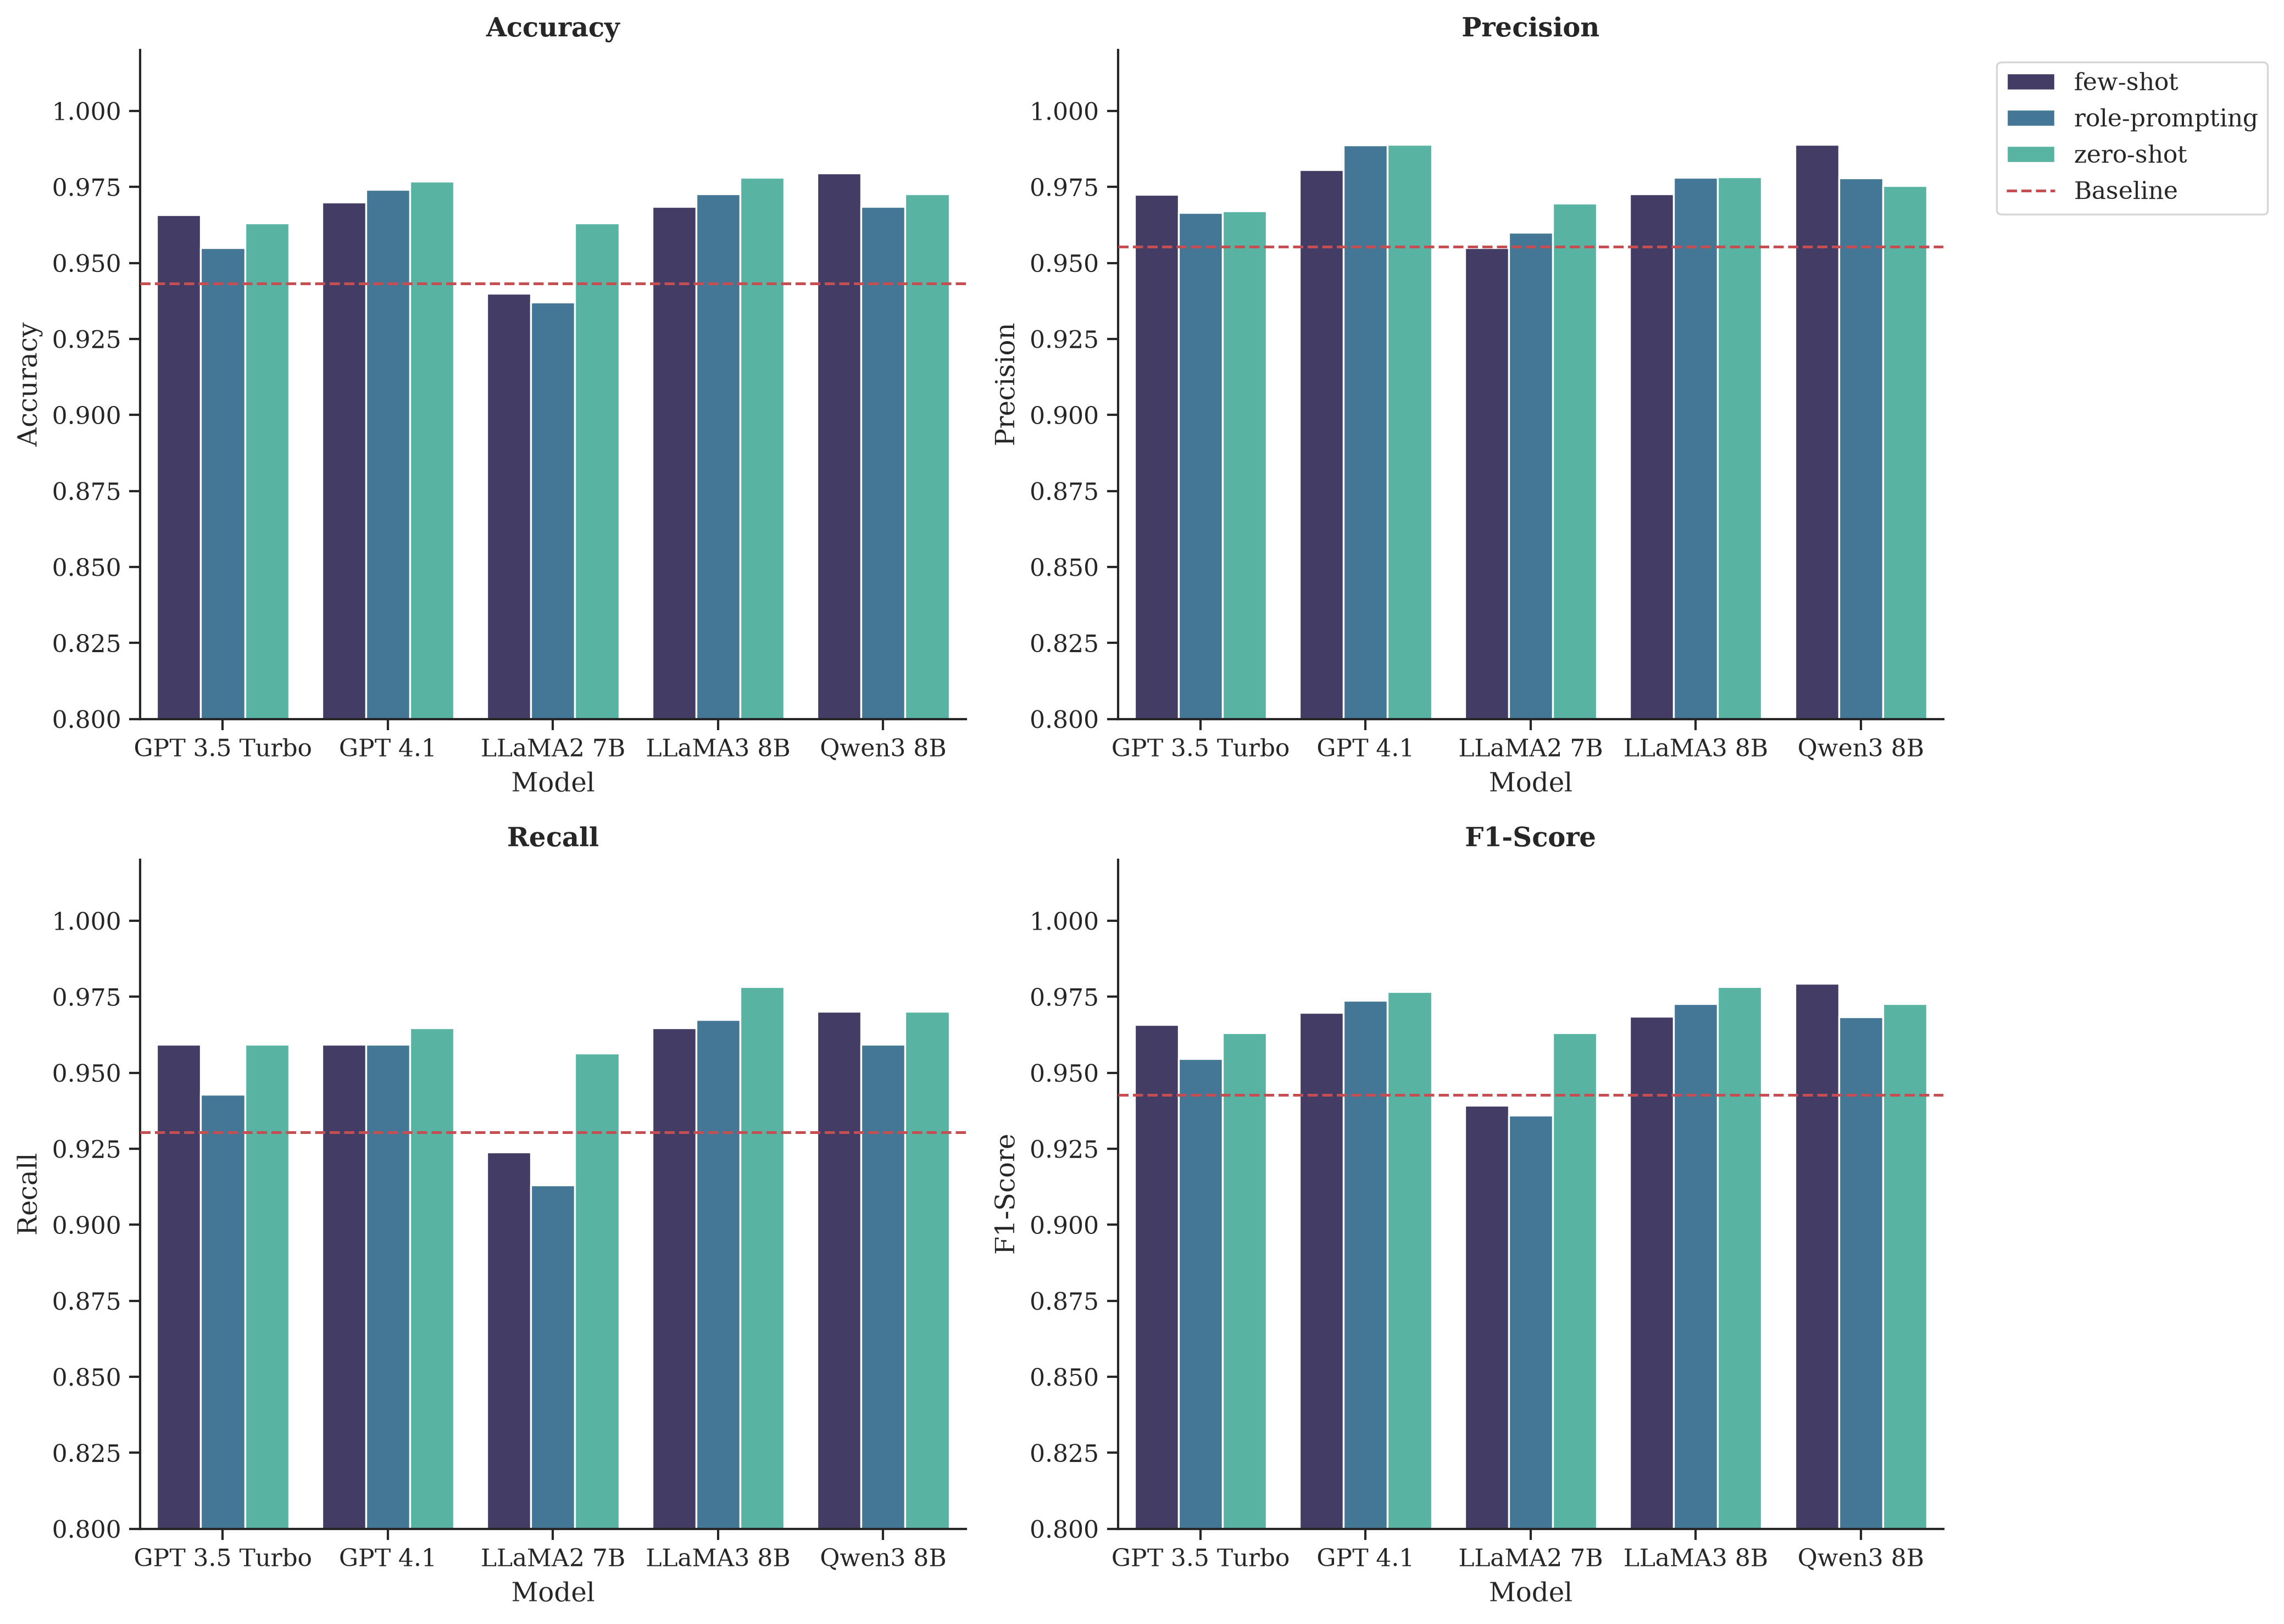

[*] Grafik ROC Curve diekspor: 20260913182453_roc_curve.png


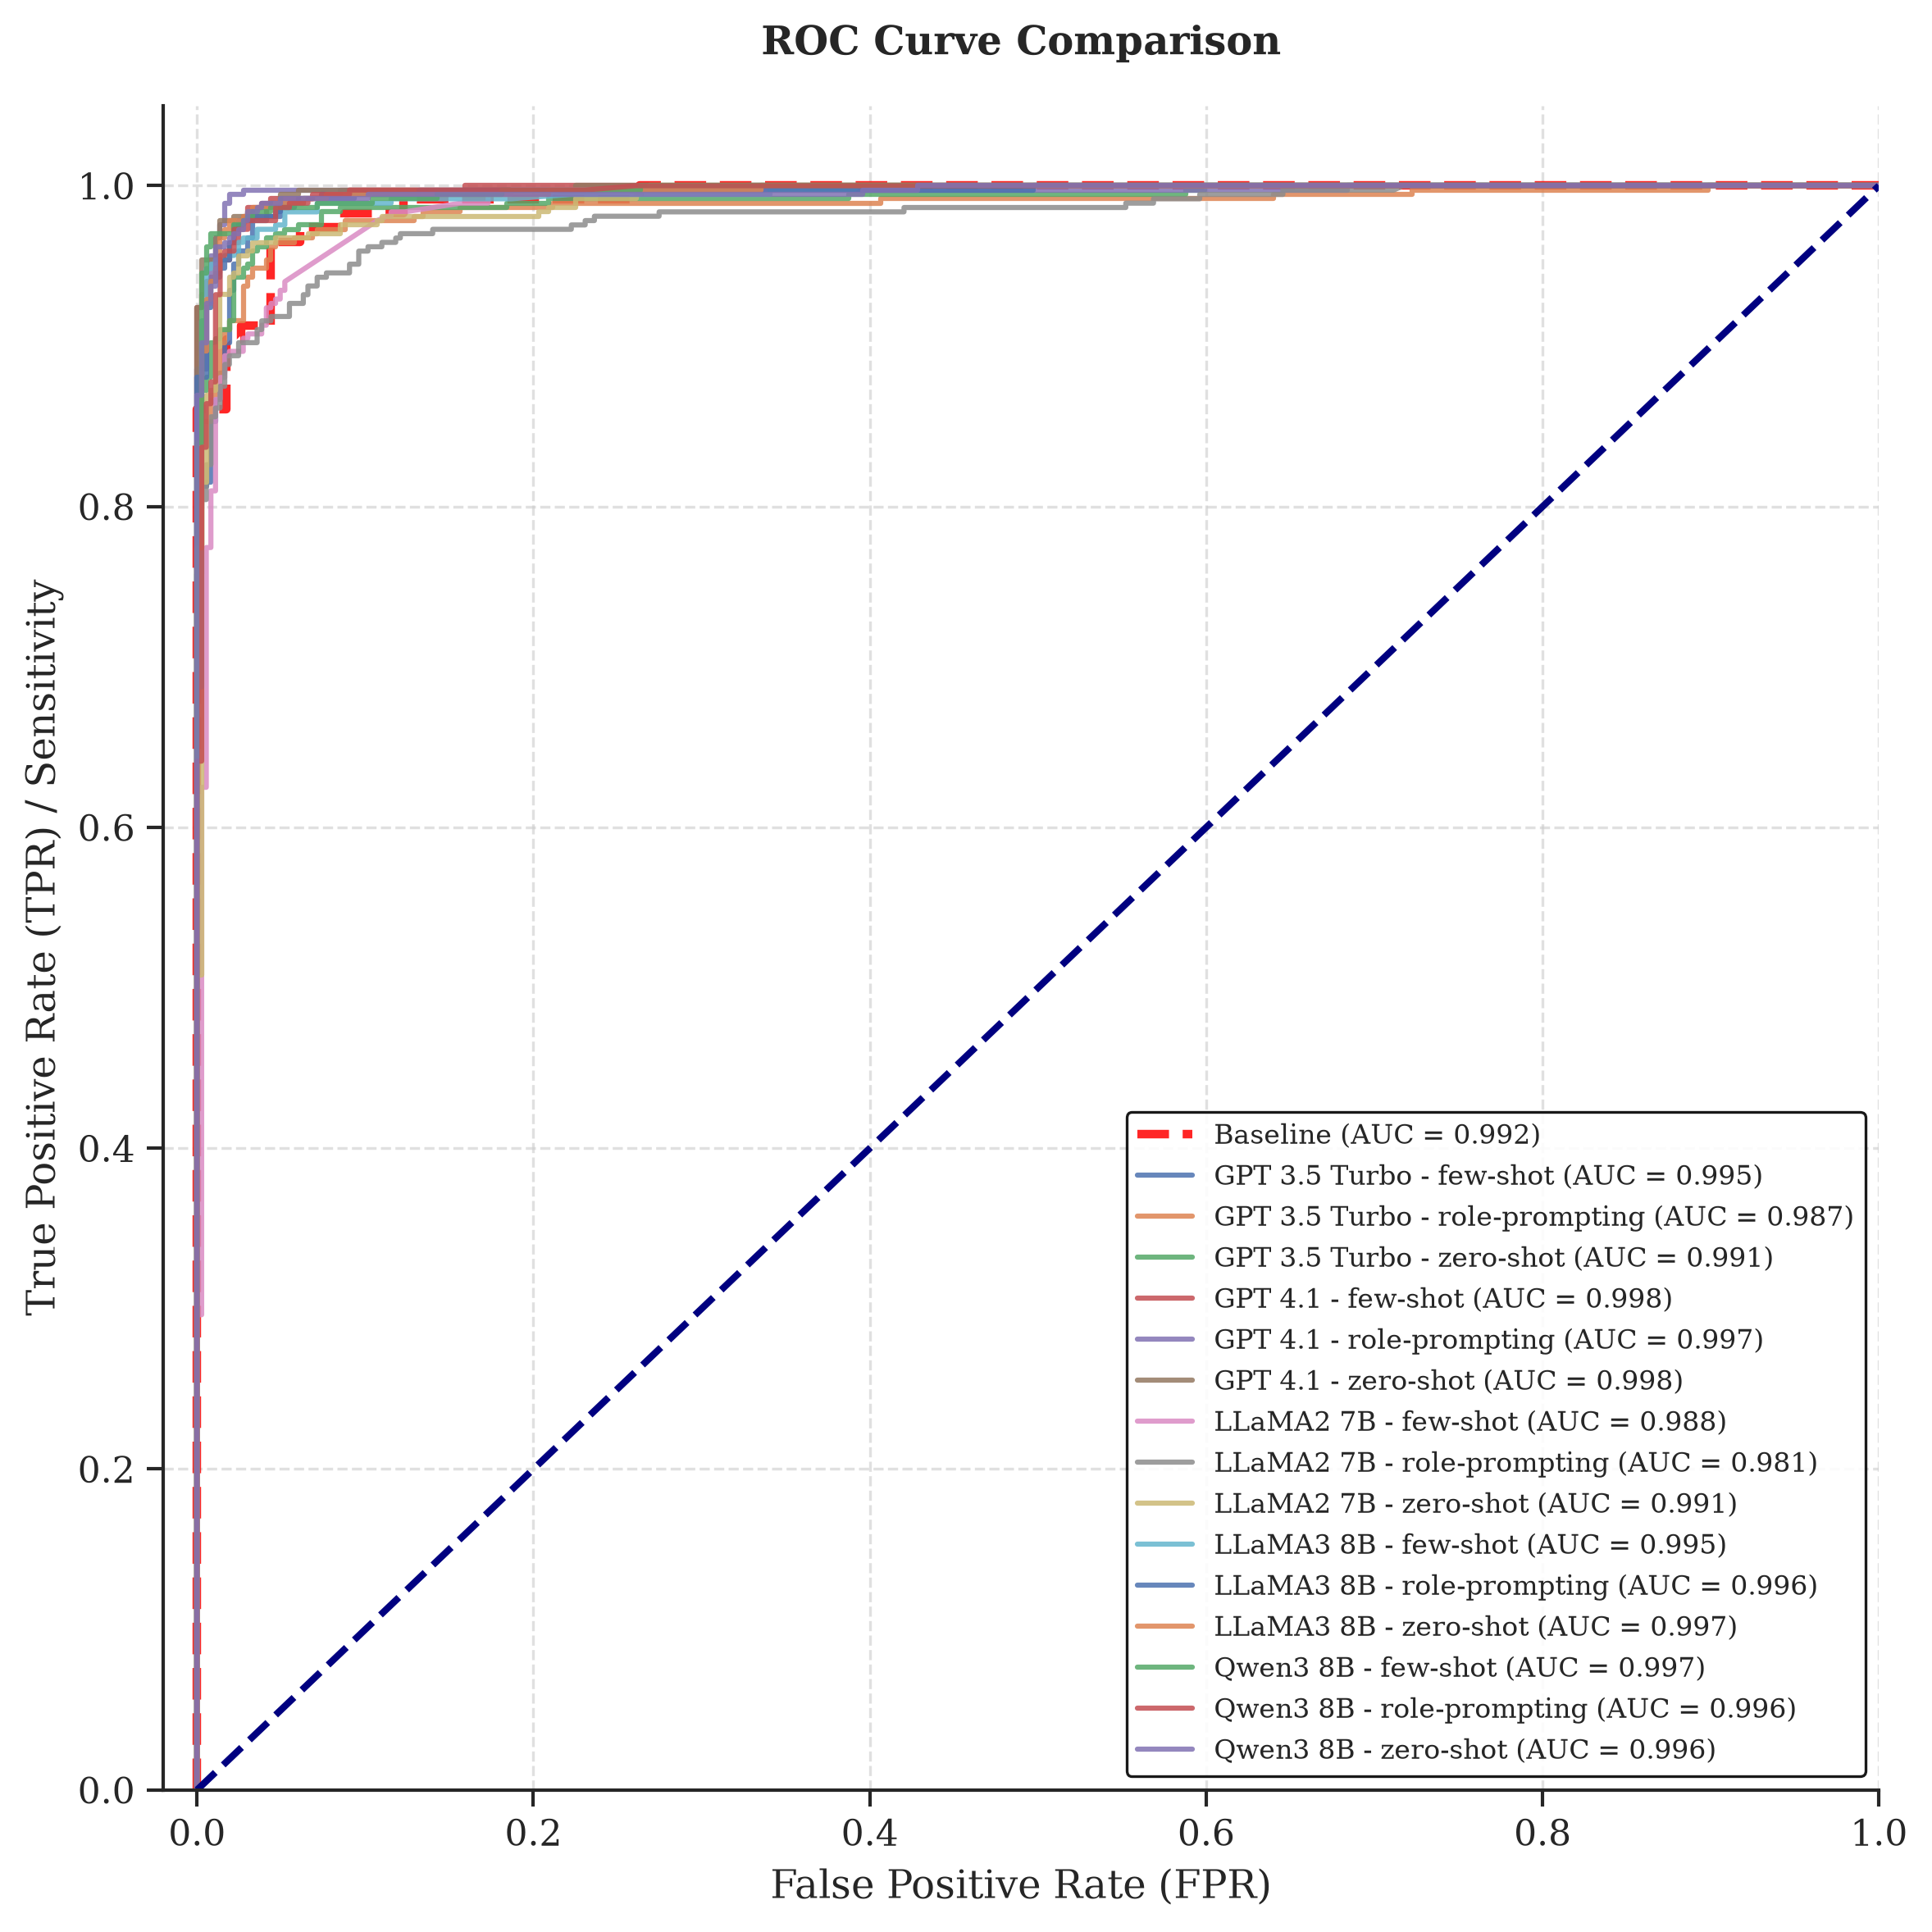

In [11]:
TIMESTAMP = "20260913182453"
RAW_DATA_PATH = os.path.join("data", "raw", "sms_spam_indo.csv")
MERGED_DIR = os.path.join("data", "augmented", TIMESTAMP, "merged", "balanced")

print(f"Memproses data klasifikasi dari: {MERGED_DIR}")

def evaluate_classification(df):
    vectorizer = TfidfVectorizer(max_features=5000)
    X = vectorizer.fit_transform(df['Pesan'].astype(str)).toarray()
    y = df['Kategori'].map({'ham': 0, 'normal': 0, 'spam': 1}).values
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    xgb = XGBClassifier(eval_metric='logloss', use_label_encoder=False, random_state=42)
    xgb.fit(X_train, y_train)
    
    y_pred = xgb.predict(X_test)
    y_prob = xgb.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    
    return {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': auc(fpr, tpr),
        'fpr': fpr, 'tpr': tpr
    }

print("Melatih Model Klasifikasi XGBoost...")

results_list, roc_data = [], []
df_raw = pd.read_csv(RAW_DATA_PATH)
base_res = evaluate_classification(df_raw)
base_roc = {'Model': 'Baseline', 'Technique': 'None', 'fpr': base_res.pop('fpr'), 'tpr': base_res.pop('tpr'), 'auc': base_res['ROC-AUC']}
base_res.update({'Model': 'Baseline', 'Technique': 'None'})
results_list.append(base_res)
roc_data.append(base_roc)

for file in glob.glob(os.path.join(MERGED_DIR, "*.csv")):
    model_name, technique = parse_model_technique(os.path.basename(file))
    df_merged = pd.read_csv(file).dropna(subset=['Pesan', 'Kategori'])
    res = evaluate_classification(df_merged)
    roc_data.append({'Model': model_name, 'Technique': technique, 'fpr': res.pop('fpr'), 'tpr': res.pop('tpr'), 'auc': res['ROC-AUC']})
    res.update({'Model': model_name, 'Technique': technique})
    results_list.append(res)

df_clf = pd.DataFrame(results_list)[['Model', 'Technique', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']]

export_table_to_png(df_clf.round(4), f"{TIMESTAMP}_tbl_classification.png", "XGBoost Classification Performance")
display(df_clf.round(4))

df_plot = df_clf[df_clf['Model'] != 'Baseline'].copy()
df_plot = df_plot.sort_values(by=['Model', 'Technique']) 
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
tech_palette = sns.color_palette("mako", n_colors=df_plot['Technique'].nunique())

for m in metrics:
    fig, ax = plt.subplots(figsize=(7, 5))
    baseline_val = df_clf[df_clf['Model'] == 'Baseline'][m].iloc[0]
    sns.barplot(data=df_plot, x='Model', y=m, hue='Technique', palette=tech_palette, ax=ax, zorder=2)
    ax.axhline(y=baseline_val, color='r', linestyle='--', label='Baseline', zorder=3)
    ax.set_title(f'Classification {m}', fontweight='bold', pad=15)
    ax.set_ylim(0.8, 1.02)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(os.path.join(output_fig_dir, f"{TIMESTAMP}_clf_{m.lower()}.png"))
    plt.close(fig)

fig_comb, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for i, m in enumerate(metrics):
    baseline_val = df_clf[df_clf['Model'] == 'Baseline'][m].iloc[0]
    sns.barplot(data=df_plot, x='Model', y=m, hue='Technique', palette=tech_palette, ax=axes[i], zorder=2)
    axes[i].axhline(y=baseline_val, color='r', linestyle='--', label='Baseline', zorder=3)
    axes[i].set_title(m, fontweight='bold')
    axes[i].set_ylim(0.8, 1.02)
    if i == 1: 
        axes[i].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    else:
        axes[i].get_legend().remove()

plt.tight_layout()
plt.savefig(os.path.join(output_fig_dir, f"{TIMESTAMP}_clf_combined.png"))
print(f"[*] Grafik Gabungan Klasifikasi diekspor: {TIMESTAMP}_clf_combined.png")
plt.show()

plt.figure(figsize=(8, 8)) 

for data in roc_data:
    label = f"Baseline (AUC = {data['auc']:.3f})" if data['Model'] == 'Baseline' else f"{data['Model']} - {data['Technique']} (AUC = {data['auc']:.3f})"
    linestyle = '--' if data['Model'] == 'Baseline' else '-'
    linewidth = 2.5 if data['Model'] == 'Baseline' else 1.5
    color = 'red' if data['Model'] == 'Baseline' else None
    
    plt.plot(data['fpr'], data['tpr'], label=label, linestyle=linestyle, linewidth=linewidth, color=color, alpha=0.85)

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([-0.02, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR) / Sensitivity')
plt.title('ROC Curve Comparison', fontweight='bold', pad=15)
plt.grid(True, linestyle='--', alpha=0.6)

plt.legend(loc="lower right", fontsize=8, framealpha=0.9, edgecolor='black')

plt.tight_layout()
plt.savefig(os.path.join(output_fig_dir, f"{TIMESTAMP}_roc_curve.png"), bbox_inches='tight')
print(f"[*] Grafik ROC Curve diekspor: {TIMESTAMP}_roc_curve.png")
plt.show()

Memproses Metrik Kualitas Teks (BERTScore, ROUGE-L, BLEU)...
[*] Tabel diekspor: results/tables/20260913182453_tbl_text_quality.png


,Model,Technique,BERTScore,ROUGE-L,BLEU
0,GPT_3.5_Turbo,few-shot,0.7812,0.4816,0.1491
1,GPT_3.5_Turbo,role-prompting,0.7644,0.4146,0.1210
2,GPT_3.5_Turbo,zero-shot,0.7756,0.4512,0.1461
3,GPT_4.1,few-shot,0.8052,0.4957,0.1367
4,GPT_4.1,role-prompting,0.7995,0.4600,0.1141
5,GPT_4.1,zero-shot,0.8044,0.4778,0.1238
6,LLaMA2_7B,few-shot,0.8584,0.7020,0.5427
7,LLaMA2_7B,role-prompting,0.8168,0.6121,0.4256
8,LLaMA2_7B,zero-shot,0.8503,0.7045,0.4870
9,LLaMA3_8B,few-shot,0.8167,0.5999,0.2492


[*] Grafik Gabungan Kualitas Teks diekspor: 20260913182453_quality_combined.png


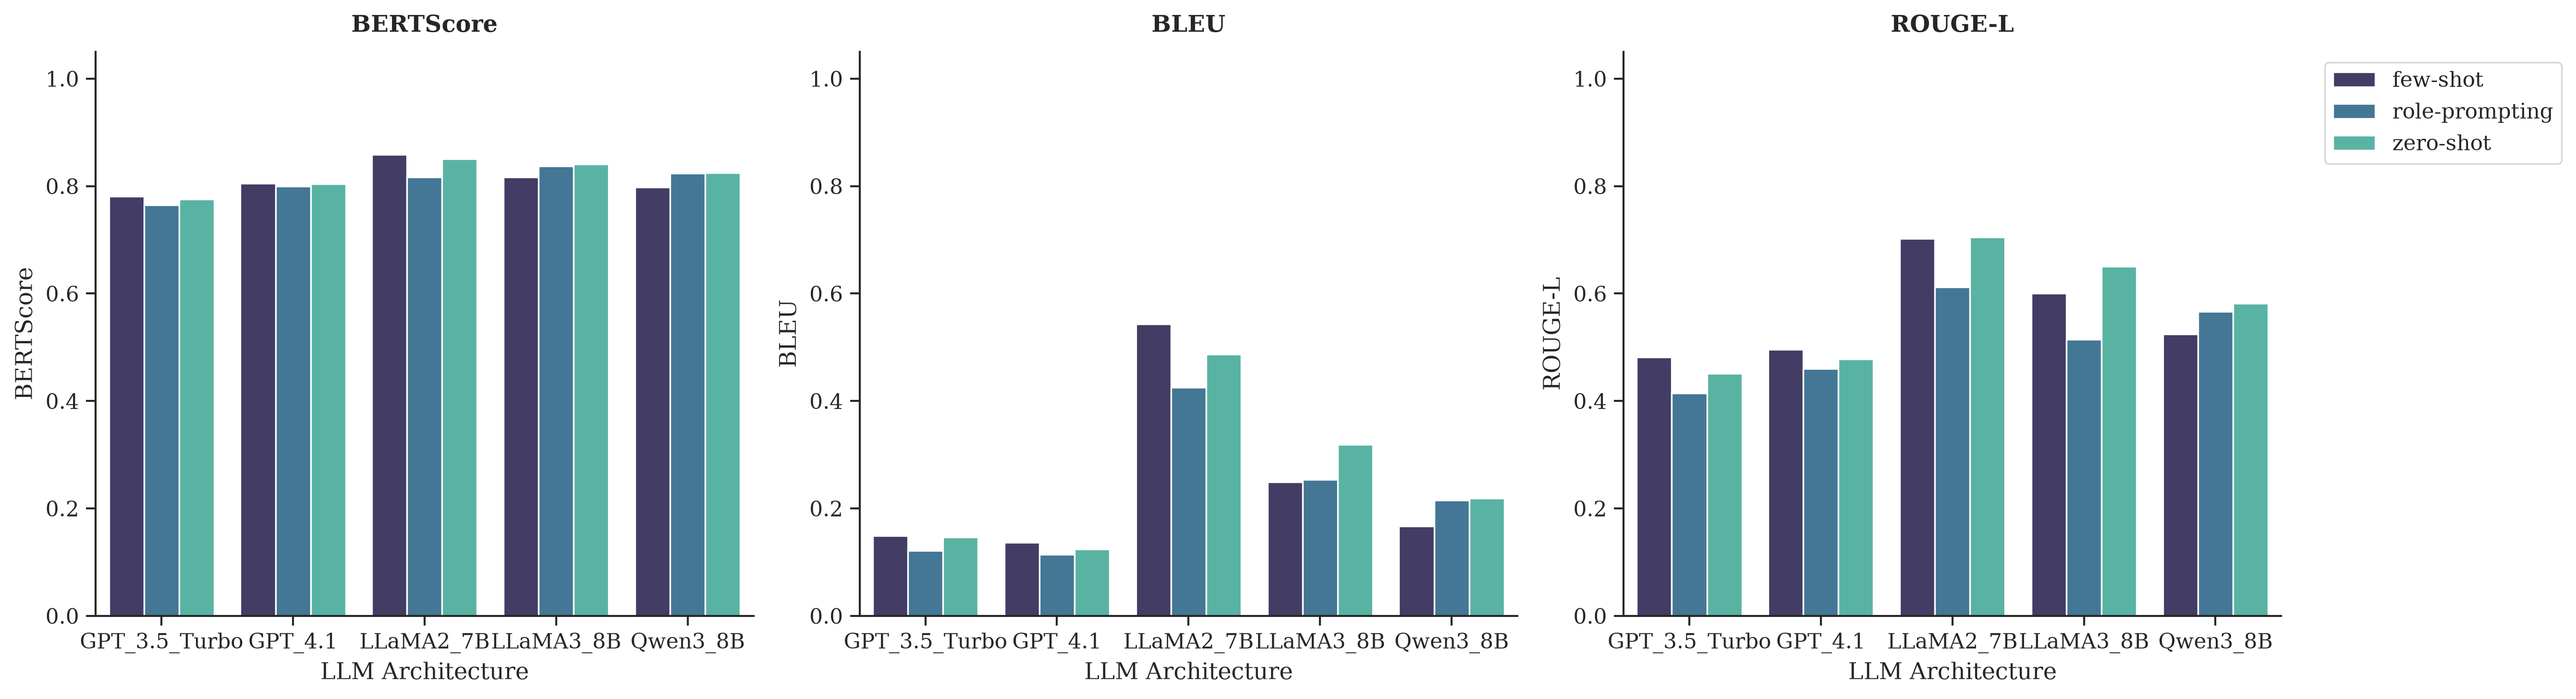

In [15]:
print("Memproses Metrik Kualitas Teks (BERTScore, ROUGE-L, BLEU)...")

EVAL_DIR = os.path.join("results", "evaluation", f"{TIMESTAMP}-evaluation")
summary_path = os.path.join(EVAL_DIR, "Summary_TextQuality.csv")

if os.path.exists(summary_path):
    df_quality = pd.read_csv(summary_path)
    
    cols_to_keep = ['Model', 'Technique', 'BERT_score', 'ROUGE_score', 'BLEU']
    df_quality_clean = df_quality[cols_to_keep].copy()
    df_quality_clean.rename(columns={'BERT_score': 'BERTScore', 'ROUGE_score': 'ROUGE-L'}, inplace=True)
    
    export_table_to_png(df_quality_clean.round(4), f"{TIMESTAMP}_tbl_text_quality.png", "Synthetic Text Quality Metrics")
    display(df_quality_clean.round(4))

    df_plot_q = df_quality_clean.sort_values(by=['Model', 'Technique'])
    tech_palette = sns.color_palette("mako", n_colors=df_plot_q['Technique'].nunique())
    metrics_q = ['BERTScore', 'BLEU', 'ROUGE-L']

    for m in metrics_q:
        fig, ax = plt.subplots(figsize=(7, 5))
        sns.barplot(data=df_plot_q, x='Model', y=m, hue='Technique', palette=tech_palette, ax=ax, edgecolor='white')
        ax.set_title(f'{m} Score', fontweight='bold', pad=15)
        ax.set_ylabel('Score')
        ax.set_xlabel('LLM Architecture')
        ax.set_ylim(0, 1.05)
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.savefig(os.path.join(output_fig_dir, f"{TIMESTAMP}_quality_indv_{m.lower().replace('-', '_')}.png"))
        plt.close(fig)

    fig_comb, axes = plt.subplots(1, 3, figsize=(18, 5))
    for i, m in enumerate(metrics_q):
        sns.barplot(data=df_plot_q, x='Model', y=m, hue='Technique', palette=tech_palette, ax=axes[i], edgecolor='white')
        axes[i].set_title(m, fontweight='bold', pad=10)
        axes[i].set_ylim(0, 1.05)
        axes[i].set_xlabel('LLM Architecture')
        if i == 2:
            axes[i].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        else:
            axes[i].get_legend().remove()

    plt.tight_layout()
    plt.savefig(os.path.join(output_fig_dir, f"{TIMESTAMP}_quality_combined.png"))
    print(f"[*] Grafik Gabungan Kualitas Teks diekspor: {TIMESTAMP}_quality_combined.png")
    plt.show()

else:
    print(f"[!] ERROR: File {summary_path} tidak ditemukan.")

Menganalisis Rata-Rata Jumlah Kata (Word Count)...
[*] Grafik Word Count diekspor: 20260913182453_avg_word_count.png


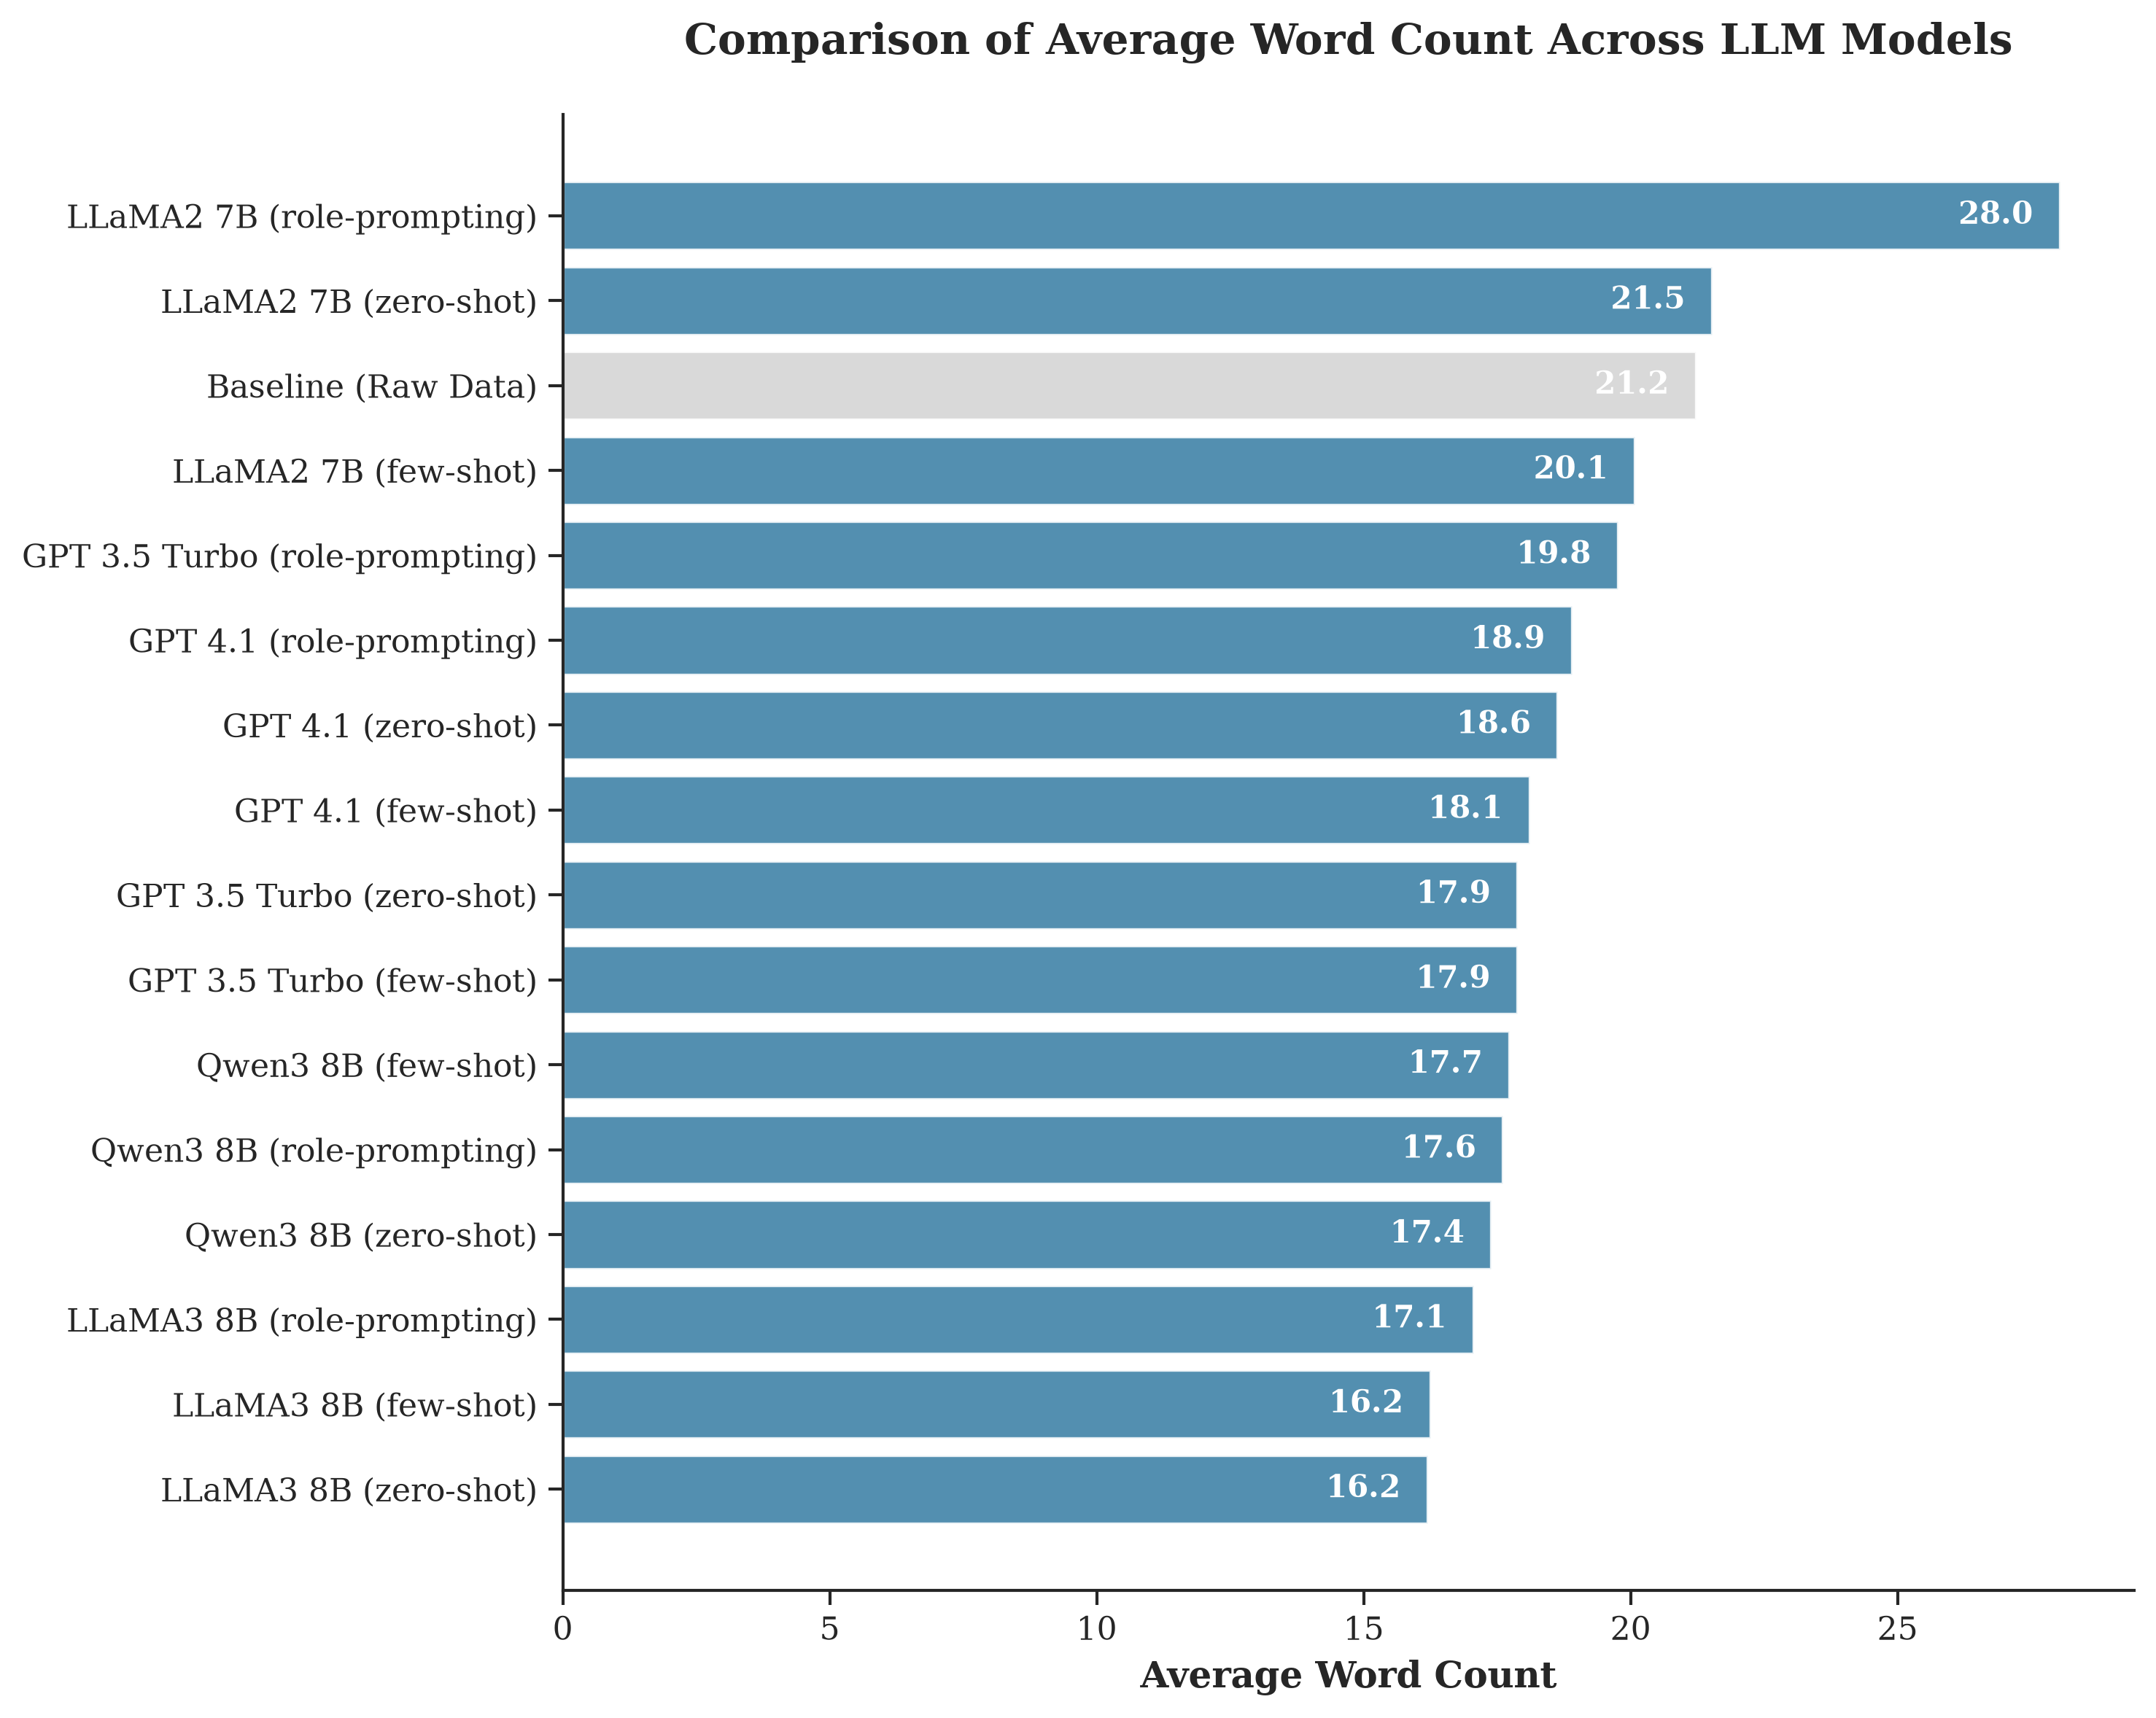

In [17]:
print("Menganalisis Rata-Rata Jumlah Kata (Word Count)...")

word_counts = []

raw_spam = df_raw[df_raw['Kategori'] == 'spam'].copy()
raw_spam['word_count'] = raw_spam['Pesan'].apply(lambda x: len(str(x).split()))
base_avg = raw_spam['word_count'].mean()
word_counts.append({'Model': 'Baseline', 'Teknik': 'Raw Data', 'Avg_Word_Count': base_avg})

SYNTHETIC_DIR = os.path.join("data", "augmented", TIMESTAMP, "synthetic")

for file in glob.glob(os.path.join(SYNTHETIC_DIR, "*.csv")):
    model_name, technique = parse_model_technique(os.path.basename(file))
    try:
        df_syn = pd.read_csv(file)
        if 'Pesan' in df_syn.columns:
            df_syn['word_count'] = df_syn['Pesan'].apply(lambda x: len(str(x).split()))
            avg_wc = df_syn['word_count'].mean()
            word_counts.append({'Model': model_name, 'Teknik': technique, 'Avg_Word_Count': avg_wc})
    except Exception as e:
        print(f"Gagal memproses {file}: {e}")

df_wc = pd.DataFrame(word_counts)
df_wc = df_wc.sort_values(by='Avg_Word_Count', ascending=False)
df_wc['Label'] = df_wc.apply(lambda row: f"{row['Model']} ({row['Teknik']})", axis=1)

base_color = sns.color_palette("mako", 1)[0] 
colors = ['#d3d3d3' if 'Baseline' in label else base_color for label in df_wc['Label']]

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(df_wc['Label'], df_wc['Avg_Word_Count'], color=colors, alpha=0.85)

ax.set_xlabel('Average Word Count', fontweight='bold', fontsize=12)
ax.set_title('Comparison of Average Word Count Across LLM Models', fontweight='bold', fontsize=14, pad=20)
ax.invert_yaxis() # Urutkan dari yang terbanyak di atas

for bar in bars:
    width = bar.get_width()
    ax.text(width - 0.5,  
            bar.get_y() + bar.get_height()/2, 
            f'{width:.1f}', 
            ha='right', va='center', 
            fontweight='bold', color='white' if width > 15 else 'black', fontsize=10)

plt.tight_layout()
plt_filename = f"{TIMESTAMP}_avg_word_count.png"
plt.savefig(os.path.join(output_fig_dir, plt_filename), bbox_inches='tight', dpi=300)
print(f"[*] Grafik Word Count diekspor: {plt_filename}")
plt.show()

## Wilcoxon test

In [19]:
import os
import glob
import pandas as pd
import numpy as np
from scipy.stats import wilcoxon
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import f1_score
from xgboost import XGBClassifier
from sklearn.utils import resample

print("Melakukan Uji Statistik Wilcoxon (Bootstrap pada Data Uji)...")

train_raw_path = os.path.join("data", "raw", "train_data.csv")
test_raw_path = os.path.join("data", "raw", "test_data.csv")

df_train_raw = pd.read_csv(train_raw_path).dropna(subset=['Pesan', 'Kategori'])
df_test = pd.read_csv(test_raw_path).dropna(subset=['Pesan', 'Kategori'])

label_map = {'ham': 0, 'normal': 0, 'spam': 1}
y_test = df_test['Kategori'].map(label_map).values

vectorizer_base = TfidfVectorizer(max_features=5000)
X_train_base = vectorizer_base.fit_transform(df_train_raw['Pesan'].astype(str)).toarray()
X_test_base = vectorizer_base.transform(df_test['Pesan'].astype(str)).toarray()
y_train_base = df_train_raw['Kategori'].map(label_map).values

xgb_base = XGBClassifier(eval_metric='logloss', random_state=42)
xgb_base.fit(X_train_base, y_train_base)
y_pred_base = xgb_base.predict(X_test_base)

def calculate_bootstrap_wilcoxon(y_true, y_pred_baseline, y_pred_augmented, n_iterations=30):
    base_f1, aug_f1 = [], []
    for i in range(n_iterations):
        indices = resample(np.arange(len(y_true)), random_state=i)
        base_f1.append(f1_score(y_true[indices], y_pred_baseline[indices], zero_division=0))
        aug_f1.append(f1_score(y_true[indices], y_pred_augmented[indices], zero_division=0))
        
    stat, p_value = wilcoxon(base_f1, aug_f1, zero_method='zsplit')
    return np.mean(base_f1), np.mean(aug_f1), p_value

wilcoxon_results = []
MERGED_DIR = os.path.join("data", "augmented", TIMESTAMP, "merged", "balanced")

for file in glob.glob(os.path.join(MERGED_DIR, "*.csv")):
    model_name, technique = parse_model_technique(os.path.basename(file))
    df_merged = pd.read_csv(file).dropna(subset=['Pesan', 'Kategori'])
    
    vectorizer_aug = TfidfVectorizer(max_features=5000)
    X_train_aug = vectorizer_aug.fit_transform(df_merged['Pesan'].astype(str)).toarray()
    X_test_aug = vectorizer_aug.transform(df_test['Pesan'].astype(str)).toarray()
    y_train_aug = df_merged['Kategori'].map(label_map).values
    
    xgb_aug = XGBClassifier(eval_metric='logloss', random_state=42)
    xgb_aug.fit(X_train_aug, y_train_aug)
    y_pred_aug = xgb_aug.predict(X_test_aug)
    
    avg_base, avg_aug, p_val = calculate_bootstrap_wilcoxon(y_test, y_pred_base, y_pred_aug)
    
    is_significant = "Yes" if p_val < 0.05 else "No"
    
    wilcoxon_results.append({
        'Model': model_name,
        'Teknik': technique,
        'Base F1': round(avg_base, 4),
        'Aug F1': round(avg_aug, 4),
        'P-Value': format(p_val, '.4e'),  
        'Significant (p < 0.05)': is_significant
    })

df_wilcoxon = pd.DataFrame(wilcoxon_results).sort_values(by=['Model', 'Teknik'])

export_table_to_png(df_wilcoxon, f"{TIMESTAMP}_tbl_wilcoxon.png", "Wilcoxon Signed-Rank Test Results")
display(df_wilcoxon)

Melakukan Uji Statistik Wilcoxon (Bootstrap pada Data Uji)...
[*] Tabel diekspor: results/tables/20260913182453_tbl_wilcoxon.png


,Model,Teknik,Base F1,Aug F1,P-Value,Significant (p < 0.05)
0,GPT 3.5 Turbo,few-shot,0.9423,0.9479,4.1724e-02,Yes
1,GPT 3.5 Turbo,role-prompting,0.9423,0.9475,3.4537e-02,Yes
2,GPT 3.5 Turbo,zero-shot,0.9423,0.9629,1.0744e-05,Yes
3,GPT 4.1,few-shot,0.9423,0.9775,1.8626e-09,Yes
4,GPT 4.1,role-prompting,0.9423,0.9775,1.8626e-09,Yes
5,GPT 4.1,zero-shot,0.9423,0.9689,1.8626e-09,Yes
6,LLaMA2 7B,few-shot,0.9423,0.9728,1.8626e-09,Yes
7,LLaMA2 7B,role-prompting,0.9423,0.9785,1.8626e-09,Yes
8,LLaMA2 7B,zero-shot,0.9423,0.9650,2.4753e-06,Yes
9,LLaMA3 8B,few-shot,0.9423,0.9747,1.8626e-09,Yes
